In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("diamonds.csv")

In [2]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


x- length 
y- width 
z- depth

In [12]:
df.shape

(53940, 11)

In [13]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [14]:
#----------------hypo tests-------------------
#----------------cut vs price----------------
import scipy.stats as stats

df['cut'] = df['cut'].astype('category')

Fair = df[df['cut'] == 'Fair']['price']
Good = df[df['cut'] == 'Good']['price']
Very_Good = df[df['cut'] == 'Very Good']['price']
Premium = df[df['cut'] == 'Premium']['price']
Ideal = df[df['cut'] == 'Ideal']['price']

anova_result = stats.f_oneway(Fair, Good, Very_Good, Premium, Ideal)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes, there is a significant difference in mean price")
else:
    print("no, there is no significant difference in mean price")


P-value: 8.42830730759452e-150
yes, there is a significant difference in mean price


In [15]:
#------------------color vs price-----------------
import scipy.stats as stats

df['color'] = df['color'].astype('category')

D = df[df['color'] == 'D']['price']
E = df[df['color'] == 'E']['price']
F = df[df['color'] == 'F']['price']
G = df[df['color'] == 'G']['price']
H = df[df['color'] == 'H']['price']
I = df[df['color'] == 'I']['price']
J = df[df['color'] == 'J']['price']

anova_result = stats.f_oneway(D, E, F, G, H, I, J)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes, there is a significant difference in mean price")
else:
    print("no, there is no significant difference in mean price")

P-value: 0.0
yes, there is a significant difference in mean price


In [16]:
#--------------clarity vs price----------------
import scipy.stats as stats

df['clarity'] = df['clarity'].astype('category')

I1 = df[df['clarity'] == 'I1']['price']
SI2 = df[df['clarity'] == 'SI2']['price']
SI1 = df[df['clarity'] == 'SI1']['price']
VS2 = df[df['clarity'] == 'VS2']['price']
VS1 = df[df['clarity'] == 'VS1']['price']
VVS2 = df[df['clarity'] == 'VVS2']['price']
VVS1 = df[df['clarity'] == 'VVS1']['price']
IF = df[df['clarity'] == 'IF']['price']

anova_result = stats.f_oneway(I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)

print(f"P-value: {anova_result.pvalue}")

if anova_result.pvalue < 0.05:
    print("yes, there is a significant difference in mean price")
else:
    print("no, there is no significant difference in mean price")

P-value: 1.9190895e-316
yes, there is a significant difference in mean price


In [58]:
#CHI SQUARE
#-----------------color and clarity------------------
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['color'], df['clarity'])

chi2_stat, p_val, dof, expected = chi2_contingency(table)

print(chi2_stat)
print(p_val)

if p_val < 0.05:
    print("There is a relationship between color and clarity.")
else:
    print("There is no relationship between color and clarity.")

2047.0791639481317
0.0
There is a relationship between color and clarity.


In [59]:
#------------cut and color----------
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['cut'], df['color'])

chi2_stat, p_val, dof, expected = chi2_contingency(table)

print(chi2_stat)
print(p_val)

if p_val < 0.05:
    print("There is a relationship between cut and color.")
else:
    print("There is no relationship between cut and color.")

310.31790052115434
1.394512091985105e-51
There is a relationship between cut and color.


In [60]:
#---------cut and clarity-----------
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['cut'], df['clarity'])

chi2_stat, p_val, dof, expected = chi2_contingency(table)

print(chi2_stat)
print(p_val)

if p_val < 0.05:
    print("There is a relationship between cut and clarity.")
else:
    print("There is no relationship between cut and clarity.")

4391.398067200364
0.0
There is a relationship between cut and clarity.


In [3]:
import pandas as pd
from scipy.stats import f_oneway, pearsonr

# Target column
target = "price"

# Categorical columns
categorical_cols = [
    "cut",
    "color",
    "clarity"
]

# Numerical columns
numerical_cols = [
    "carat",
    "x",
    "y",
    "z"
]

feature_results = []

# 1. ANOVA for categorical columns
for col in categorical_cols:
    if col in df.columns:

        groups = [group[target].values for _, group in df.groupby(col)]

        f_stat, p_val = f_oneway(*groups)

        feature_results.append(
            {
                "Feature": col,
                "Type": "Categorical",
                "Test Used": "One-Way ANOVA",
                "P-Value": p_val,
                "Status": "KEEP (Significant)"
                if p_val < 0.05
                else "DROP (Insignificant)",
            }
        )

# 2. Pearson Correlation for numerical columns
for col in numerical_cols:
    if col in df.columns:

        corr, p_val = pearsonr(df[col], df[target])

        feature_results.append(
            {
                "Feature": col,
                "Type": "Numerical",
                "Test Used": "Pearson Correlation",
                "P-Value": p_val,
                "Status": "KEEP (Significant)"
                if p_val < 0.05
                else "DROP (Insignificant)",
            }
        )

# Display results
result_df = pd.DataFrame(feature_results)

styled_results = result_df.style.map(
    lambda val: "background-color: #d4edda; color: #155724; font-weight:bold"
    if "KEEP" in str(val)
    else (
        "background-color: #f8d7da; color:#721c24"
        if "DROP" in str(val)
        else ""
    ),
    subset=["Status"],
).hide(axis="index")

styled_results

Feature,Type,Test Used,P-Value,Status
cut,Categorical,One-Way ANOVA,0.000000,KEEP (Significant)
color,Categorical,One-Way ANOVA,0.000000,KEEP (Significant)
clarity,Categorical,One-Way ANOVA,0.000000,KEEP (Significant)
carat,Numerical,Pearson Correlation,0.000000,KEEP (Significant)
x,Numerical,Pearson Correlation,0.000000,KEEP (Significant)
y,Numerical,Pearson Correlation,0.000000,KEEP (Significant)
z,Numerical,Pearson Correlation,0.000000,KEEP (Significant)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Unnamed: 0  53940 non-null  int64   
 1   carat       53940 non-null  float64 
 2   cut         53940 non-null  category
 3   color       53940 non-null  category
 4   clarity     53940 non-null  category
 5   depth       53940 non-null  float64 
 6   table       53940 non-null  float64 
 7   price       53940 non-null  int64   
 8   x           53940 non-null  float64 
 9   y           53940 non-null  float64 
 10  z           53940 non-null  float64 
dtypes: category(3), float64(6), int64(2)
memory usage: 3.4 MB


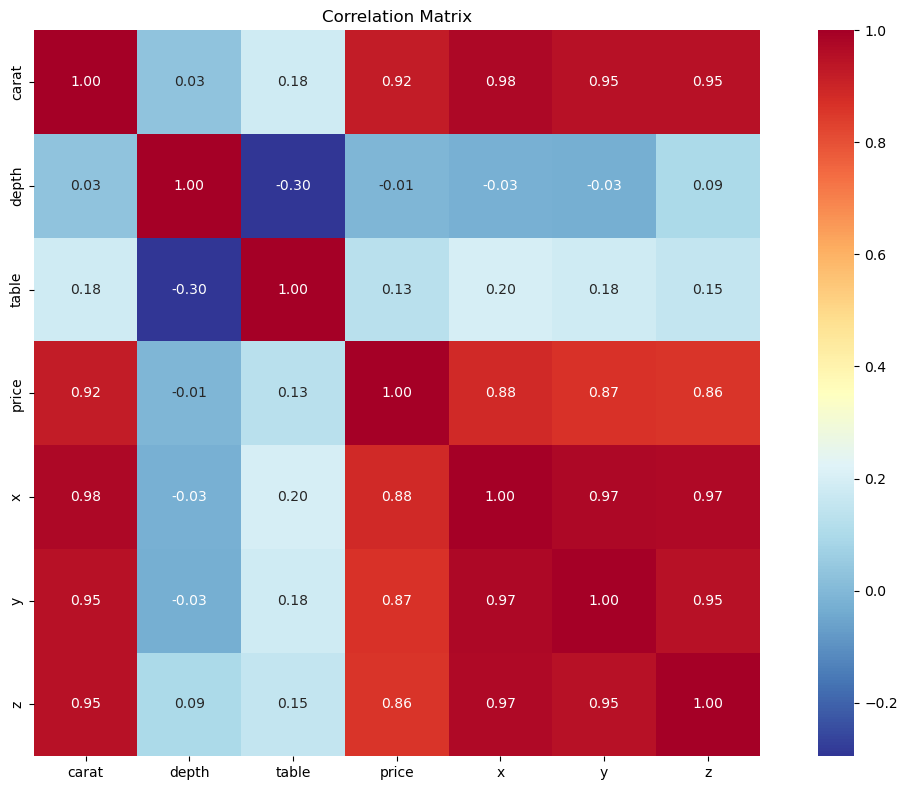

In [19]:

numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=["Unnamed: 0"])

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\VISHAL KIRTHIK\AppData\Local\Temp\ipykernel_24172\3207929033.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [3]:
df.drop(columns=["table","depth","Unnamed: 0"],inplace=True)

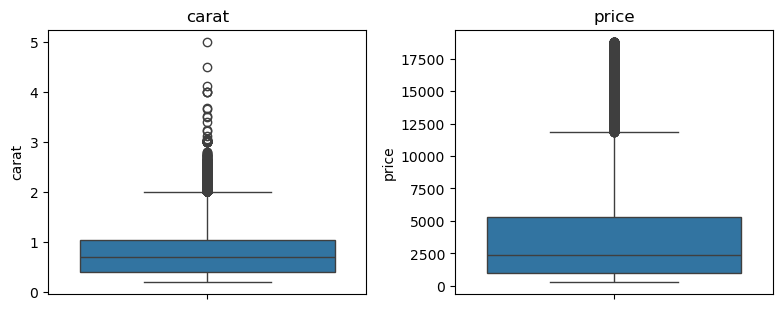

In [21]:
num_cols = ["carat","price"]

plt.figure(figsize=(12,6))
for i,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

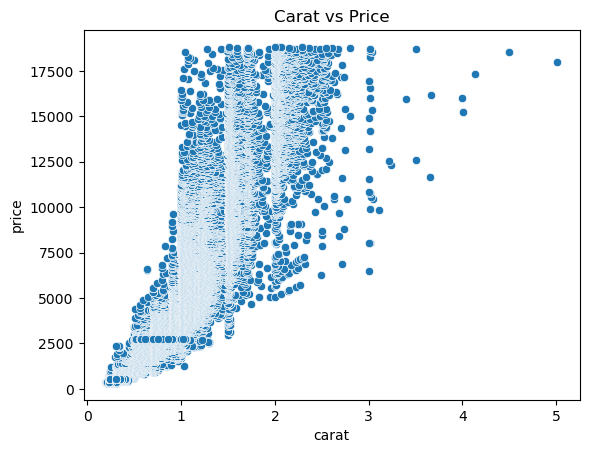

In [22]:
sns.scatterplot(data=df, x="carat", y="price")
plt.title("Carat vs Price")
plt.show()

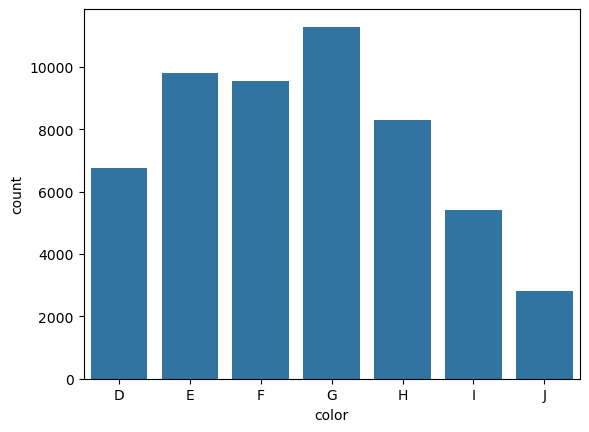

In [23]:
sns.countplot(x="color", data=df)
plt.show()

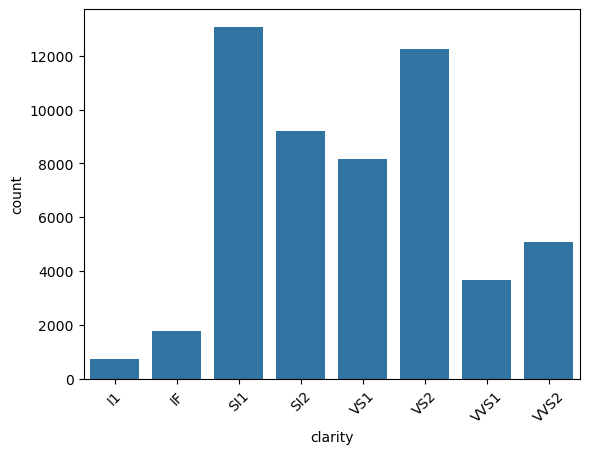

In [24]:
sns.countplot(x="clarity", data=df)
plt.xticks(rotation=45)
plt.show()

In [4]:
df

,carat,cut,color,clarity,price,x,y,z
0,0.23,2,1,3,326,3.95,3.98,2.43
1,0.21,3,1,2,326,3.89,3.84,2.31
2,0.23,1,1,4,327,4.05,4.07,2.31
3,0.29,3,5,5,334,4.20,4.23,2.63
4,0.31,1,6,3,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...
53935,0.72,2,0,2,2757,5.75,5.76,3.50
53936,0.72,1,0,2,2757,5.69,5.75,3.61
53937,0.70,4,0,2,2757,5.66,5.68,3.56
53938,0.86,3,4,3,2757,6.15,6.12,3.74


In [5]:
x = df.drop('price', axis=1)
y = df['price']

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [7]:
#--------------------------LINEAR REGRESSION------------------------
from sklearn.linear_model import LinearRegression
model=LinearRegression(fit_intercept= True, positive=False)
from sklearn.preprocessing import StandardScaler # MinMaxscaler--normalisation 
scale=StandardScaler()

In [8]:
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)
x_train_scaled

array([[ 0.86265905, -0.54179216,  0.82597664, ...,  1.05558107,
         0.98655568,  0.9682529 ],
       [-1.02988861, -0.54179216, -0.93837264, ..., -1.20773446,
        -1.20254423, -1.16827649],
       [ 0.86265905, -0.54179216, -0.93837264, ...,  0.90409932,
         0.95166963,  0.98230901],
       ...,
       [-0.987832  ,  1.40380566, -0.35025621, ..., -1.10971685,
        -1.11532909, -1.1823326 ],
       [ 0.21078152,  0.43100675,  2.00220949, ...,  0.35163648,
         0.25394854,  0.39195221],
       [ 0.7154609 ,  0.43100675, -0.35025621, ...,  0.96647416,
         0.91678357,  0.79957952]], shape=(37758, 7))

In [9]:
model.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[5026.58, 78.99,-458.94,...,-987.15, 96.52,-232.33]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3951
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[390.42,196.07,190.6 ,..., 46.96, 43.39, 25.13]"


In [10]:
y_pred=model.predict(x_test_scaled)

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared Score:", r2)

Mean Squared Error: 1828839.1115084006
Mean Absolute Error: 872.5622634597293
R-squared Score: 0.882736380584307


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

model = LinearRegression()

params = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

grid = GridSearchCV(model,
                    param_grid=params,
                    cv=5,
                    scoring="r2",
                    n_jobs=-1)

grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'fit_intercept': True, 'positive': False}
0.8731544627337608


In [12]:
#--------------------------dt regressor----------------------best
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [13]:
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)
x_train_scaled

array([[ 0.86265905, -0.54179216,  0.82597664, ...,  1.05558107,
         0.98655568,  0.9682529 ],
       [-1.02988861, -0.54179216, -0.93837264, ..., -1.20773446,
        -1.20254423, -1.16827649],
       [ 0.86265905, -0.54179216, -0.93837264, ...,  0.90409932,
         0.95166963,  0.98230901],
       ...,
       [-0.987832  ,  1.40380566, -0.35025621, ..., -1.10971685,
        -1.11532909, -1.1823326 ],
       [ 0.21078152,  0.43100675,  2.00220949, ...,  0.35163648,
         0.25394854,  0.39195221],
       [ 0.7154609 ,  0.43100675, -0.35025621, ...,  0.96647416,
         0.91678357,  0.79957952]], shape=(37758, 7))

In [14]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(criterion= 'squared_error', max_depth= 10, min_samples_leaf= 1, min_samples_split=10)

In [15]:
model.fit(x_train_scaled,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes

In [16]:
y_pred=model.predict(x_test_scaled)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared Score:", r2)

Mean Squared Error: 402990.5335698614
Mean Absolute Error: 341.31948297038167
R-squared Score: 0.9741605873041029


In [24]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)

params = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["squared_error", "friedman_mse"]
}

grid = GridSearchCV(model, params, cv=5, scoring="r2", n_jobs=-1)
grid.fit(x_train, y_train)

print(grid.best_params_)

{'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [62]:
#-------------------------------rf regressor------------------------- 
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200)

In [63]:
model.fit(x_train_scaled,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
y_pred=model.predict(x_test_scaled)

In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared Score:", r2)

Mean Squared Error: 296514.8246056775
Mean Absolute Error: 271.4665836185802
R-squared Score: 0.9809877198465026


In [66]:
train_score = model.score(x_train_scaled, y_train)
print("Training R2 Score:", train_score)

Training R2 Score: 0.9952840411198064


In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Model
rf = RandomForestRegressor(random_state=42)

# Small parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search
grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# Train
grid.fit(x_train, y_train)

# Best model
best_rf = grid.best_estimator_

# Prediction
y_pred = best_rf.predict(x_test)

# Results
print("Best Parameters:", grid.best_params_)
print("Best R² Score:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best R² Score: 0.9794393312447647


In [67]:
#---------------------------knn regressor-------------------------
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score

In [68]:
from sklearn.preprocessing import StandardScaler 
scale=StandardScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)
x_train_scaled

array([[ 0.86265905, -0.54179216,  0.82597664, ...,  1.05558107,
         0.98655568,  0.9682529 ],
       [-1.02988861, -0.54179216, -0.93837264, ..., -1.20773446,
        -1.20254423, -1.16827649],
       [ 0.86265905, -0.54179216, -0.93837264, ...,  0.90409932,
         0.95166963,  0.98230901],
       ...,
       [-0.987832  ,  1.40380566, -0.35025621, ..., -1.10971685,
        -1.11532909, -1.1823326 ],
       [ 0.21078152,  0.43100675,  2.00220949, ...,  0.35163648,
         0.25394854,  0.39195221],
       [ 0.7154609 ,  0.43100675, -0.35025621, ...,  0.96647416,
         0.91678357,  0.79957952]], shape=(37758, 7))

In [75]:
model=KNeighborsRegressor(n_neighbors=7,metric='euclidean',weights= 'distance')
model.fit(x_train_scaled,y_train)

,n_neighbors,7
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [76]:
y_pred=model.predict(x_test_scaled)

In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared Score:", r2)

Mean Squared Error: 409112.7129259635
Mean Absolute Error: 301.4841977036478
R-squared Score: 0.9737680383338349


In [78]:
train_score = model.score(x_train_scaled, y_train)
print("Training R2 Score:", train_score)

Training R2 Score: 0.9999908994421528


In [74]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()

params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(model, params, cv=5, scoring="r2")

grid.fit(x_train_scaled, y_train)

print(grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
